# 🔍 Data Inspection — AI4I 2020 Predictive Maintenance

This notebook performs a thorough inspection of the **AI4I 2020 Predictive Maintenance Dataset**  
before any preprocessing or modelling steps.

**Dataset:** [UCI ML Repository — AI4I 2020](https://archive.ics.uci.edu/ml/datasets/AI4I+2020+Predictive+Maintenance+Dataset)  
**Goal:** Binary classification — predict `Machine failure` (0 / 1)  
**Model target:** Decision Tree Classifier

---
### Notebook Structure
1. Import Libraries  
2. Load Dataset  
3. Shape & Column Overview  
4. Data Types & Memory Usage  
5. Statistical Summary  
6. Missing Value Analysis  
7. Duplicate Detection  
8. Target Variable Analysis (Class Imbalance)  
9. Feature Distributions  
10. Outlier Detection (IQR Method)  
11. Correlation Analysis  
12. Failure Type Breakdown  
13. Inspection Summary


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Dataset

In [4]:
df = pd.read_csv(r'C:\Users\shais\iot-predictive-maintenance\Dataset\ai4i2020.csv')
print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 10000 rows × 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Shape & Column Overview

In [5]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()
print("Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Rows    : 10000
Columns : 14

Column Names:
   1. UDI
   2. Product ID
   3. Type
   4. Air temperature [K]
   5. Process temperature [K]
   6. Rotational speed [rpm]
   7. Torque [Nm]
   8. Tool wear [min]
   9. Machine failure
  10. TWF
  11. HDF
  12. PWF
  13. OSF
  14. RNF


## 4. Data Types & Memory Usage

In [6]:
dtype_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': df.dtypes.values,
    'Non-Null Count': df.notnull().sum().values,
    'Null Count': df.isnull().sum().values
})
print(dtype_df.to_string(index=False))
print()
print(f"Total memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

                 Column   Dtype  Non-Null Count  Null Count
                    UDI   int64           10000           0
             Product ID  object           10000           0
                   Type  object           10000           0
    Air temperature [K] float64           10000           0
Process temperature [K] float64           10000           0
 Rotational speed [rpm]   int64           10000           0
            Torque [Nm] float64           10000           0
        Tool wear [min]   int64           10000           0
        Machine failure   int64           10000           0
                    TWF   int64           10000           0
                    HDF   int64           10000           0
                    PWF   int64           10000           0
                    OSF   int64           10000           0
                    RNF   int64           10000           0

Total memory usage: 2119.27 KB


## 5. Statistical Summary

In [7]:
print("=== Numerical Columns ===")
display(df.describe().T.style.background_gradient(cmap='Blues'))

=== Numerical Columns ===


,count,mean,std,min,25%,50%,75%,max
UDI,10000.000000,5000.500000,2886.895680,1.000000,2500.750000,5000.500000,7500.250000,10000.000000
Air temperature [K],10000.000000,300.004930,2.000259,295.300000,298.300000,300.100000,301.500000,304.500000
Process temperature [K],10000.000000,310.005560,1.483734,305.700000,308.800000,310.100000,311.100000,313.800000
Rotational speed [rpm],10000.000000,1538.776100,179.284096,1168.000000,1423.000000,1503.000000,1612.000000,2886.000000
Torque [Nm],10000.000000,39.986910,9.968934,3.800000,33.200000,40.100000,46.800000,76.600000
Tool wear [min],10000.000000,107.951000,63.654147,0.000000,53.000000,108.000000,162.000000,253.000000
Machine failure,10000.000000,0.033900,0.180981,0.000000,0.000000,0.000000,0.000000,1.000000
TWF,10000.000000,0.004600,0.067671,0.000000,0.000000,0.000000,0.000000,1.000000
HDF,10000.000000,0.011500,0.106625,0.000000,0.000000,0.000000,0.000000,1.000000
PWF,10000.000000,0.009500,0.097009,0.000000,0.000000,0.000000,0.000000,1.000000


In [8]:
print("=== Categorical Columns ===")
display(df[['Type', 'Product ID']].describe())

=== Categorical Columns ===


,Type,Product ID
count,10000,10000
unique,3,10000
top,L,L57163
freq,6000,1


## 6. Missing Value Analysis

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage (%)': missing_pct.round(2)
})

print(missing_df.to_string())
print()
if missing.sum() == 0:
    print("✅ No missing values found in the dataset.")
else:
    print(f"⚠️ Total missing values: {missing.sum()}")

                         Missing Values  Percentage (%)
UDI                                   0             0.0
Product ID                            0             0.0
Type                                  0             0.0
Air temperature [K]                   0             0.0
Process temperature [K]               0             0.0
Rotational speed [rpm]                0             0.0
Torque [Nm]                           0             0.0
Tool wear [min]                       0             0.0
Machine failure                       0             0.0
TWF                                   0             0.0
HDF                                   0             0.0
PWF                                   0             0.0
OSF                                   0             0.0
RNF                                   0             0.0

✅ No missing values found in the dataset.


## 7. Duplicate Detection

In [10]:
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count == 0:
    print("✅ No duplicate rows found.")
else:
    print(f"⚠️ {dup_count} duplicate rows detected.")
    display(df[df.duplicated(keep=False)].head(10))

Duplicate rows: 0
✅ No duplicate rows found.


## 8. Target Variable Analysis (Class Imbalance)

Machine Failure Distribution:
  Class 0 (No Failure) : 9661 rows  (96.61%)
  Class 1 (Failure)    : 339 rows  (3.39%)
  Imbalance Ratio      : 28.5:1


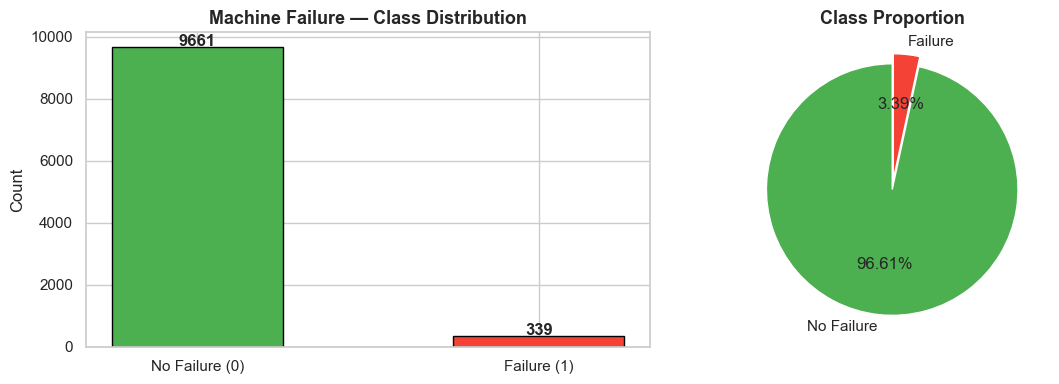


⚠️  Severe class imbalance detected (28.5:1). Must be handled before modelling.


In [11]:
target_counts = df['Machine failure'].value_counts()
target_pct = df['Machine failure'].value_counts(normalize=True) * 100

print("Machine Failure Distribution:")
print(f"  Class 0 (No Failure) : {target_counts[0]} rows  ({target_pct[0]:.2f}%)")
print(f"  Class 1 (Failure)    : {target_counts[1]} rows  ({target_pct[1]:.2f}%)")
print(f"  Imbalance Ratio      : {target_counts[0]/target_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(['No Failure (0)', 'Failure (1)'], target_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
axes[0].set_title('Machine Failure — Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.2f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print()
print("⚠️  Severe class imbalance detected (28.5:1). Must be handled before modelling.")

## 9. Feature Distributions

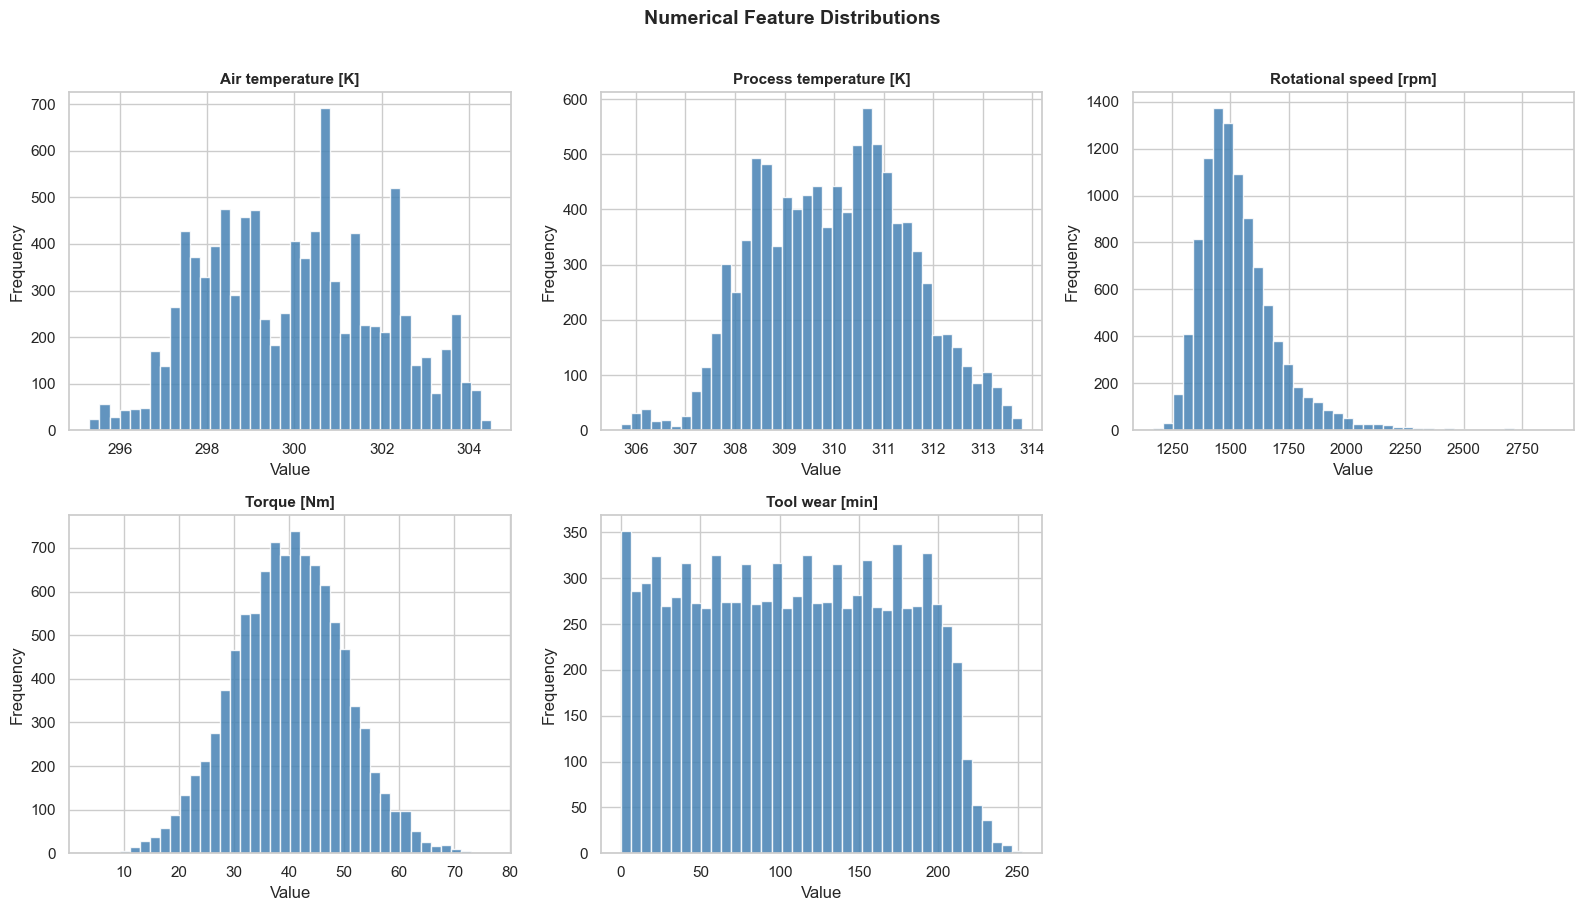

In [12]:
num_features = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[5].axis('off')
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

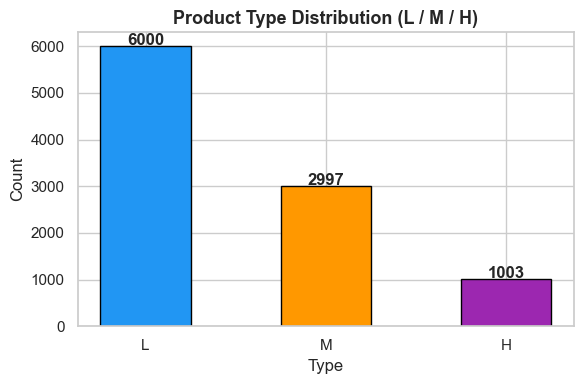

In [13]:
# Type distribution
fig, ax = plt.subplots(figsize=(6, 4))
type_counts = df['Type'].value_counts()
bars = ax.bar(type_counts.index, type_counts.values,
              color=['#2196F3', '#FF9800', '#9C27B0'], edgecolor='black', width=0.5)
ax.set_title('Product Type Distribution (L / M / H)', fontsize=13, fontweight='bold')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Outlier Detection (IQR Method)

In [14]:
print("Outlier Count per Feature (IQR method):\n")
outlier_summary = {}
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_summary[col] = len(outliers)
    print(f"  {col:<35} → {len(outliers):>4} outliers  (bounds: [{lower:.2f}, {upper:.2f}])")

print()
print("Note: Decision Trees are inherently robust to outliers (split-based, not distance-based).")

Outlier Count per Feature (IQR method):

  Air temperature [K]                 →    0 outliers  (bounds: [293.50, 306.30])
  Process temperature [K]             →    0 outliers  (bounds: [305.35, 314.55])
  Rotational speed [rpm]              →  418 outliers  (bounds: [1139.50, 1895.50])
  Torque [Nm]                         →   69 outliers  (bounds: [12.80, 67.20])
  Tool wear [min]                     →    0 outliers  (bounds: [-110.50, 325.50])

Note: Decision Trees are inherently robust to outliers (split-based, not distance-based).


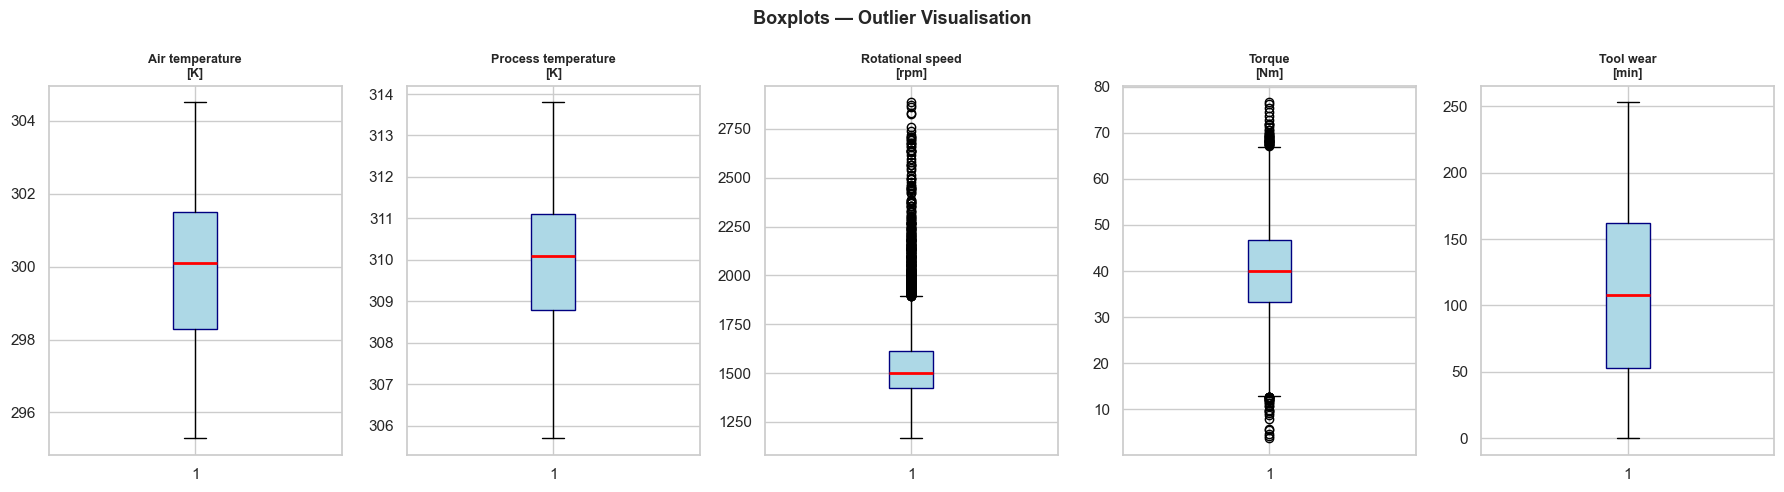

In [15]:
fig, axes = plt.subplots(1, len(num_features), figsize=(18, 5))

for i, col in enumerate(num_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.replace(' [', '\n['), fontsize=9, fontweight='bold')

plt.suptitle('Boxplots — Outlier Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

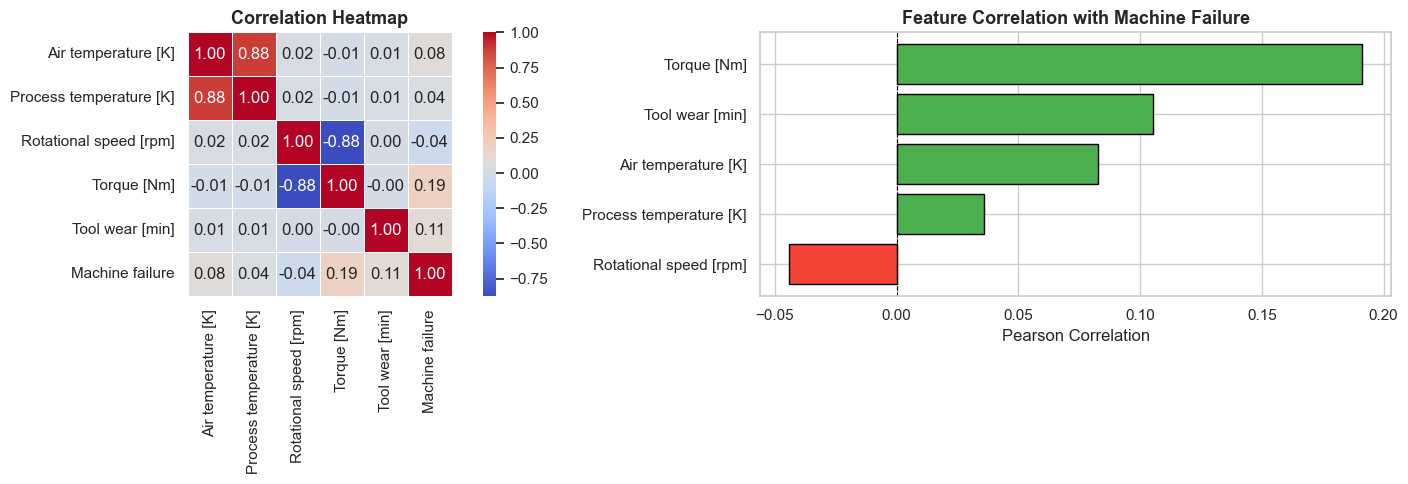


Correlation with target (Machine failure):
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188


In [16]:
corr_cols = num_features + ['Machine failure']
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0], square=True)
axes[0].set_title('Correlation Heatmap', fontsize=13, fontweight='bold')

# Bar chart — correlation with target
target_corr = corr_matrix['Machine failure'].drop('Machine failure').sort_values(ascending=True)
colors = ['#F44336' if v < 0 else '#4CAF50' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Feature Correlation with Machine Failure', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.show()

print("\nCorrelation with target (Machine failure):")
print(target_corr.sort_values(ascending=False).to_string())

## 12. Failure Type Breakdown

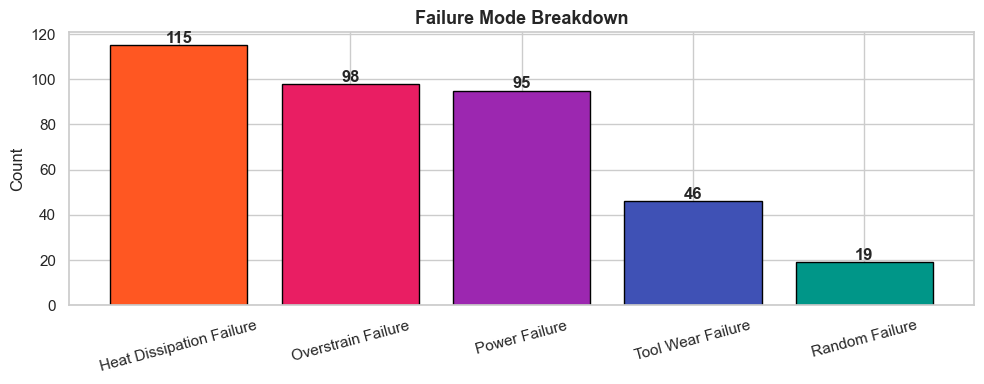


Failure Type Counts:
  Tool Wear Failure             : 46
  Heat Dissipation Failure      : 115
  Power Failure                 : 95
  Overstrain Failure            : 98
  Random Failure                : 19


In [17]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = {
    'TWF': 'Tool Wear Failure',
    'HDF': 'Heat Dissipation Failure',
    'PWF': 'Power Failure',
    'OSF': 'Overstrain Failure',
    'RNF': 'Random Failure'
}

counts = {failure_names[k]: df[k].sum() for k in failure_types}
counts_series = pd.Series(counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(counts_series.index, counts_series.values,
              color=['#FF5722','#E91E63','#9C27B0','#3F51B5','#009688'],
              edgecolor='black')
ax.set_title('Failure Mode Breakdown', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts_series.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nFailure Type Counts:")
for k, v in counts.items():
    print(f"  {k:<30}: {v}")

## 13. Inspection Summary

In [18]:
summary = {
    'Total Rows'              : df.shape[0],
    'Total Columns'           : df.shape[1],
    'Missing Values'          : df.isnull().sum().sum(),
    'Duplicate Rows'          : df.duplicated().sum(),
    'Class Imbalance Ratio'   : f"{df['Machine failure'].value_counts()[0] / df['Machine failure'].value_counts()[1]:.1f}:1",
    'Outliers (RPM)'          : 418,
    'Outliers (Torque)'       : 69,
    'Strongest Predictor'     : 'Torque [Nm] (corr=0.19)',
    'Categorical Columns'     : 'Type, Product ID',
    'Identifier Columns'      : 'UDI, Product ID (to be dropped)',
}

print("=" * 52)
print("         DATA INSPECTION SUMMARY")
print("=" * 52)
for k, v in summary.items():
    print(f"  {k:<30}: {v}")
print("=" * 52)
print()
print("Key findings:")
print("  1. No missing values or duplicates — dataset is structurally clean.")
print("  2. Severe class imbalance (28.5:1) must be addressed in preprocessing.")
print("  3. UDI and Product ID are identifiers — drop before training.")
print("  4. Type column needs encoding (L/M/H → 0/1/2).")
print("  5. Decision Tree is robust to outliers — no removal needed.")
print("  6. Torque and Tool wear are the most correlated features with failure.")
print()
print("→ Proceed to: 02_preprocessing.ipynb")

         DATA INSPECTION SUMMARY
  Total Rows                    : 10000
  Total Columns                 : 14
  Missing Values                : 0
  Duplicate Rows                : 0
  Class Imbalance Ratio         : 28.5:1
  Outliers (RPM)                : 418
  Outliers (Torque)             : 69
  Strongest Predictor           : Torque [Nm] (corr=0.19)
  Categorical Columns           : Type, Product ID
  Identifier Columns            : UDI, Product ID (to be dropped)

Key findings:
  1. No missing values or duplicates — dataset is structurally clean.
  2. Severe class imbalance (28.5:1) must be addressed in preprocessing.
  3. UDI and Product ID are identifiers — drop before training.
  4. Type column needs encoding (L/M/H → 0/1/2).
  5. Decision Tree is robust to outliers — no removal needed.
  6. Torque and Tool wear are the most correlated features with failure.

→ Proceed to: 02_preprocessing.ipynb
